In [1]:
# KMeans: Huấn luyện mô hình cho bài toán Phân cụm (Học không giám sát)
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')  # Tắt cảnh báo bộ nhớ trên một số máy

In [4]:
def train_kmeans_model(X, k=5):
    """
    Hàm khởi tạo và huấn luyện mô hình K-Means truyền thống.
    - init='random': Sử dụng thuật toán K-Means gốc (chọn tâm ngẫu nhiên).
    """
    start_time = time.time()

    # Khởi tạo mô hình K-Means thường
    model = KMeans(n_clusters=k, init='random', n_init=10, random_state=42)

    # Huấn luyện mô hình (Chỉ cần truyền X vì không có nhãn y)
    model.fit(X)

    execution_time = time.time() - start_time

    return model, execution_time

In [5]:
def evaluate_kmeans_model(X, model):
    """
    Hàm đánh giá chất lượng phân cụm bằng Silhouette Score.
    """
    # Lấy nhãn cụm mà mô hình đã gán cho từng điểm dữ liệu
    labels = model.labels_

    print("=" * 45)
    print("BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM")

    # Tính điểm Silhouette
    sil_score = silhouette_score(X, labels)

    print("\n--- Đánh giá bằng Silhouette Score (Từ -1 đến 1) ---")
    print(f"=> Điểm Silhouette của mô hình: {sil_score:.4f}")
    if sil_score > 0.5:
        print("   (Đánh giá: Phân cụm khá tốt, các nhóm tách bạch rõ ràng)")
    else:
        print("   (Đánh giá: Phân cụm chưa tốt lắm, các nhóm có thể bị chồng chéo)")
    print("=" * 45)

In [6]:
def plot_kmeans_results(X, model, features_to_plot):
    plt.figure(figsize=(9, 6))

    labels = model.labels_
    centroids = model.cluster_centers_
    unique_clusters = np.unique(labels)

    # Danh sách màu sắc cho các cụm (Hỗ trợ 5 cụm theo bài toán)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    f1, f2 = features_to_plot[0], features_to_plot[1]

    # Vẽ các điểm dữ liệu thuộc từng cụm
    for i, cluster in enumerate(unique_clusters):
        idx = labels == cluster
        plt.scatter(X.loc[idx, f1], X.loc[idx, f2],
                    color=colors[i % len(colors)], label=f'Cụm {cluster}', alpha=0.6, s=50)

    # Vẽ các tâm cụm (Centroids)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                color='black', marker='X', s=200, edgecolors='white', linewidths=2,
                label='Tâm cụm (Centroids)')

    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title('Minh hoạ phân cụm K-Means truyền thống (init=random)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

Kích thước tập dữ liệu X : 200 mẫu
HUẤN LUYỆN MÔ HÌNH VÀ TÍNH THỜI GIAN
- Cấu hình: K-Means truyền thống (init='random'), số cụm K=5
- Thời gian huấn luyện: 0.05765 giây

Dữ liệu khách hàng mới: [60, 50]
- Khách hàng này được xếp vào: Cụm 4
BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH PHÂN CỤM

--- Đánh giá bằng Silhouette Score (Từ -1 đến 1) ---
=> Điểm Silhouette của mô hình: 0.5539
   (Đánh giá: Phân cụm khá tốt, các nhóm tách bạch rõ ràng)
VẼ ĐỒ THỊ MINH HOẠ PHÂN CỤM


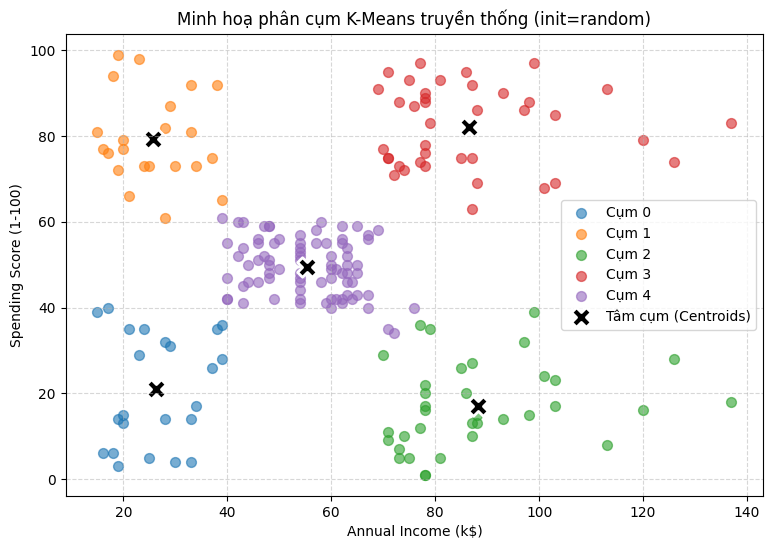

In [7]:
if __name__ == '__main__':
    # BƯỚC 1: Chuẩn bị dữ liệu
    try:
        df = pd.read_csv('Mall_Customers.csv')
    except FileNotFoundError:
        df = pd.read_csv('database/Mall_Customers.csv')

    # BƯỚC 2: Tiền xử lý dữ liệu
    # K-Means là học không giám sát nên ta không có biến y, cũng không cần chia Train/Test
    features_cols = ['Annual Income (k$)', 'Spending Score (1-100)']
    X = df[features_cols]

    print(f"Kích thước tập dữ liệu X : {len(X)} mẫu")
    print("=" * 45)

    # BƯỚC 3 & 4: Huấn luyện mô hình và tính thời gian
    print("HUẤN LUYỆN MÔ HÌNH VÀ TÍNH THỜI GIAN")
    k_clusters = 5

    # Gọi hàm huấn luyện tách rời
    trained_model, exec_time = train_kmeans_model(X, k=k_clusters)

    print(f"- Cấu hình: K-Means truyền thống (init='random'), số cụm K={k_clusters}")
    print(f"- Thời gian huấn luyện: {exec_time:.5f} giây")

    # DỰ ĐOÁN THỬ MỘT MẪU MỚI TÙY CHỌN (Khách hàng có thu nhập 60k$, tiêu xài 50đ)
    new_customer = [60, 50]
    new_customer_df = pd.DataFrame([new_customer], columns=features_cols)
    predicted_cluster = trained_model.predict(new_customer_df)[0]

    print(f"\nDữ liệu khách hàng mới: {new_customer}")
    print(f"- Khách hàng này được xếp vào: Cụm {predicted_cluster}")

    # BƯỚC 5: Đánh giá kết quả phân cụm
    evaluate_kmeans_model(X, trained_model)

    # BƯỚC 6: Vẽ đồ thị minh hoạ
    print("VẼ ĐỒ THỊ MINH HOẠ PHÂN CỤM")
    plot_kmeans_results(X, trained_model, features_cols)